# Make Figures for Fast Formation Model vs. Experiment

2024/06/13

Make clear plots of the formation data focusing on thickness expansion

Andrew Weng

In [37]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from src import plotter as plotter

%load_ext autoreload

plotter.initialize(plt)

target_dir = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plot the cycling data

In [38]:
cycling_list = ['/Users/aweng/code/formation-modeling/data/processed/UMBL2022FEB_CELL152064.pkl']

In [39]:
import pickle

# Load the pickle file
pickle_file = cycling_list[0]
with open(pickle_file, 'rb') as f:
    data = pickle.load(f)

# Print the loaded data
data

{'UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923':    [Arbin] AC Impedance (Ω)  [Arbin] AC Impedance Phase Angle (°)  \
 0                       0.0                                   0.0   
 
    [Arbin] Charge Capacity (Ah)  [Arbin] Charge Energy (Wh)  \
 0                           0.0                         0.0   
 
    [Arbin] Current (A)  [Arbin] Cycle Number  [Arbin] Datapoint Number  \
 0                  0.0                     1                         1   
 
    [Arbin] Date Time (excel format)  [Arbin] Discharge Capacity (Ah)  \
 0                      44827.357257                              0.0   
 
    [Arbin] Discharge Energy (Wh)  ...  i_cycle_num  Datapoint Number  \
 0                            0.0  ...          1.0               1.0   
 
             h_datapoint_time  h_discharge_capacity  h_discharge_energy  \
 0  2022-09-23 12:34:27+00:00                   0.0                 0.0   
 
    h_potential  h_step_index  h_step_time  h_test_time  \
 0     3.31

In [40]:
data['AuxDat'].columns

Index(['[VDF] Ambient_RH 0 (%)', 'aux_vdf_ambienttemperature_celsius_0',
       'aux_vdf_current_amp_0', '[VDF] Datapoint_Number 0', '[VDF] LDC N 0',
       'aux_vdf_ldcref_none_0', '[VDF] LDC scaled 0',
       'aux_vdf_ldcsensor_none_0', '[VDF] Potential 0 (V)', '[VDF] REF N 0',
       '[VDF] REF STD 0', '[VDF] Temperature 0 (°C)', '[VDF] Test Time 0 (s)',
       '[VDF] Timestamp 0', 'Test Cumulative Capacity (Ah)',
       'Test Cumulative Energy (Wh)', 'Test Net Capacity (Ah)',
       'Test Net Energy (Wh)', 'dQ/dV (Ah/V)', 'dV/dt (V/s)', 'Power (W)',
       'Current Cycle Net Capacity (Ah)', 'Current Cycle Net Energy (Wh)',
       'h_charge_capacity', 'h_charge_energy', 'h_current', 'i_cycle_num',
       'Datapoint Number', 'h_datapoint_time', 'h_discharge_capacity',
       'h_discharge_energy', 'h_potential', 'h_step_index', 'h_step_time',
       'h_test_time'],
      dtype='object')

In [44]:
date_format = '%Y-%m-%d %H:%M:%S.%f%z'

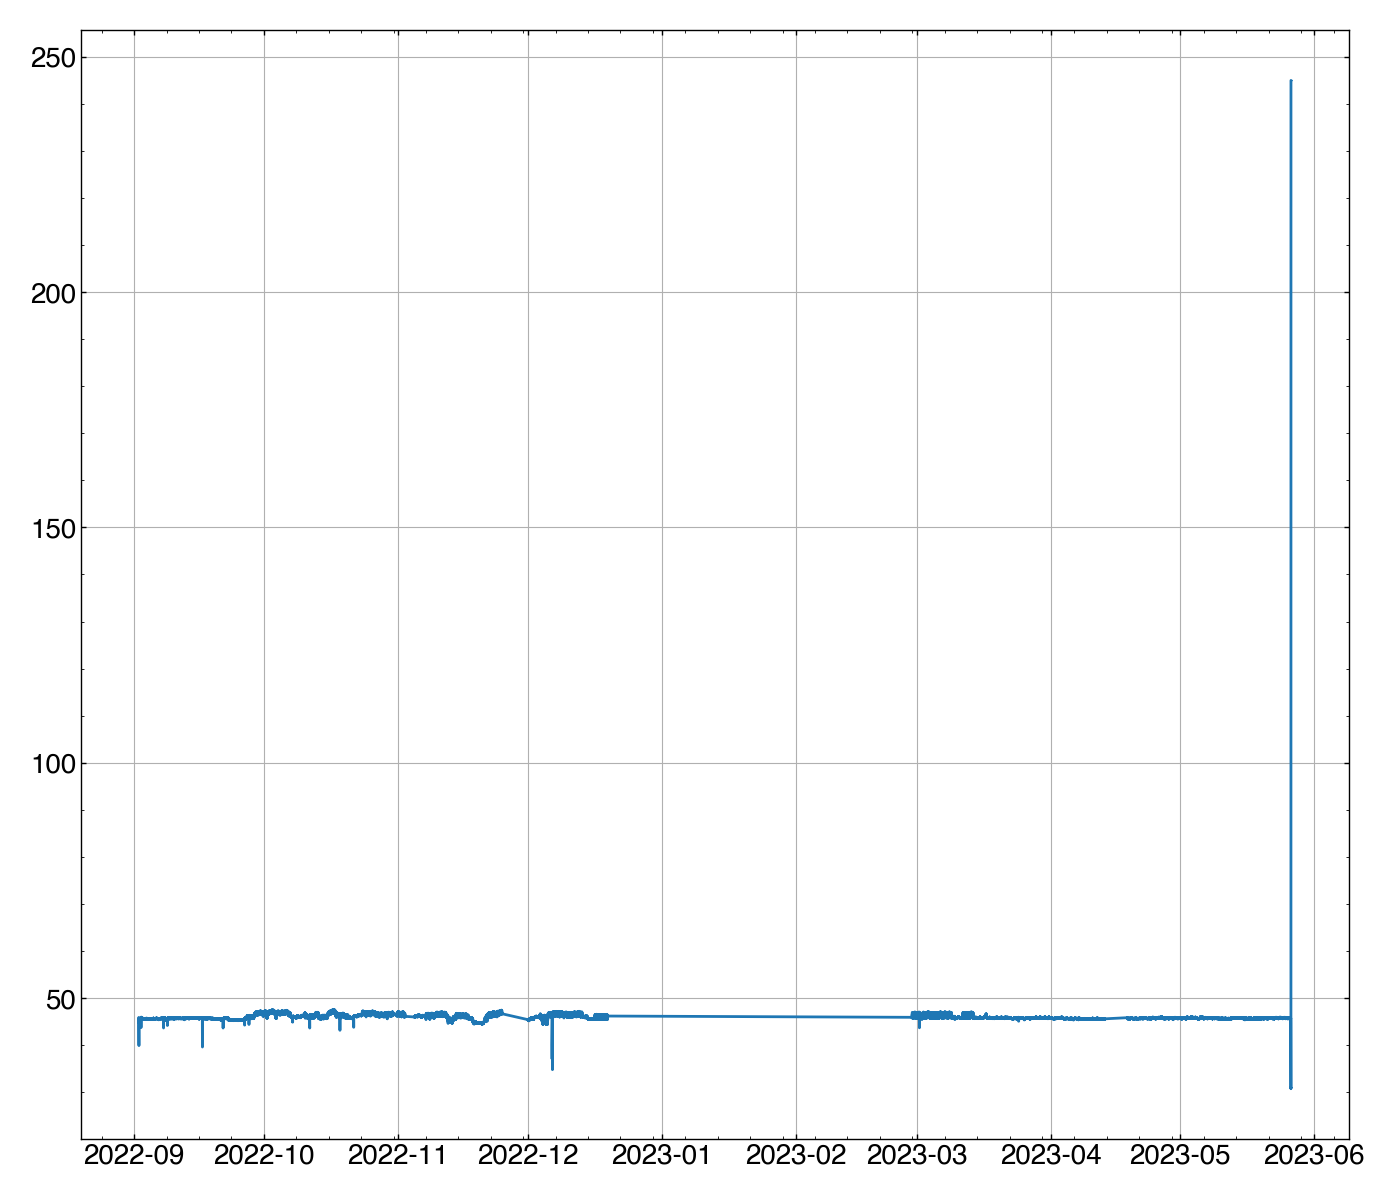

In [51]:
plt.figure()

plt.plot(pd.to_datetime(data['AuxDat']['h_datapoint_time'], format=date_format), data['AuxDat']['[VDF] Temperature 0 (°C)'])

In [17]:
data['AuxDat']

,[VDF] Ambient_RH 0 (%),aux_vdf_ambienttemperature_celsius_0,aux_vdf_current_amp_0,[VDF] Datapoint_Number 0,[VDF] LDC N 0,aux_vdf_ldcref_none_0,[VDF] LDC scaled 0,aux_vdf_ldcsensor_none_0,[VDF] Potential 0 (V),[VDF] REF N 0,...,h_current,i_cycle_num,Datapoint Number,h_datapoint_time,h_discharge_capacity,h_discharge_energy,h_potential,h_step_index,h_step_time,h_test_time
0,17.1,45.1,0.0,44888,100.0,6875294,3.312600e+04,6908420,0.0,100.0,...,0.0,0.0,44888.0,2022-09-02 01:32:00.869000+00:00,0.0,0.0,0.0,3.0,0.000000e+00,5.000201e+00
1,17.1,45.1,0.0,44889,100.0,6875163,3.317500e+04,6908338,0.0,100.0,...,0.0,0.0,44889.0,2022-09-02 01:32:05.869000+00:00,0.0,0.0,0.0,3.0,5.000907e+00,1.000111e+01
2,17.2,45.1,0.0,44890,100.0,6875059,3.307600e+04,6908135,0.0,100.0,...,0.0,0.0,44890.0,2022-09-02 01:32:10.869000+00:00,0.0,0.0,0.0,3.0,1.000013e+01,1.500033e+01
3,17.1,45.1,0.0,44891,100.0,6875072,3.321400e+04,6908286,0.0,100.0,...,0.0,0.0,44891.0,2022-09-02 01:32:15.869000+00:00,0.0,0.0,0.0,3.0,1.500102e+01,2.000122e+01
4,17.2,45.1,0.0,44892,100.0,6875088,3.327200e+04,6908360,0.0,100.0,...,0.0,0.0,44892.0,2022-09-02 01:32:20.869000+00:00,0.0,0.0,0.0,3.0,2.000107e+01,2.500127e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654673,26.0,27.4,0.0,654678,0.0,4294967295,3.676479e+07,4294967295,0.0,0.0,...,0.0,0.0,654678.0,2023-05-26 14:41:21.980000+00:00,0.0,0.0,0.0,3.0,3.273433e+06,3.273438e+06
654674,26.0,27.4,0.0,654679,0.0,4294967295,3.676479e+07,4294967295,0.0,0.0,...,0.0,0.0,654679.0,2023-05-26 14:41:26.980000+00:00,0.0,0.0,0.0,3.0,3.273438e+06,3.273443e+06
654675,26.0,27.4,0.0,654680,0.0,4294967295,3.676479e+07,4294967295,0.0,0.0,...,0.0,0.0,654680.0,2023-05-26 14:41:31.980000+00:00,0.0,0.0,0.0,3.0,3.273443e+06,3.273448e+06
654676,26.0,27.4,0.0,654681,0.0,4294967295,3.676479e+07,4294967295,0.0,0.0,...,0.0,0.0,654681.0,2023-05-26 14:41:36.980000+00:00,0.0,0.0,0.0,3.0,3.273448e+06,3.273453e+06


(0.0, 50.0)

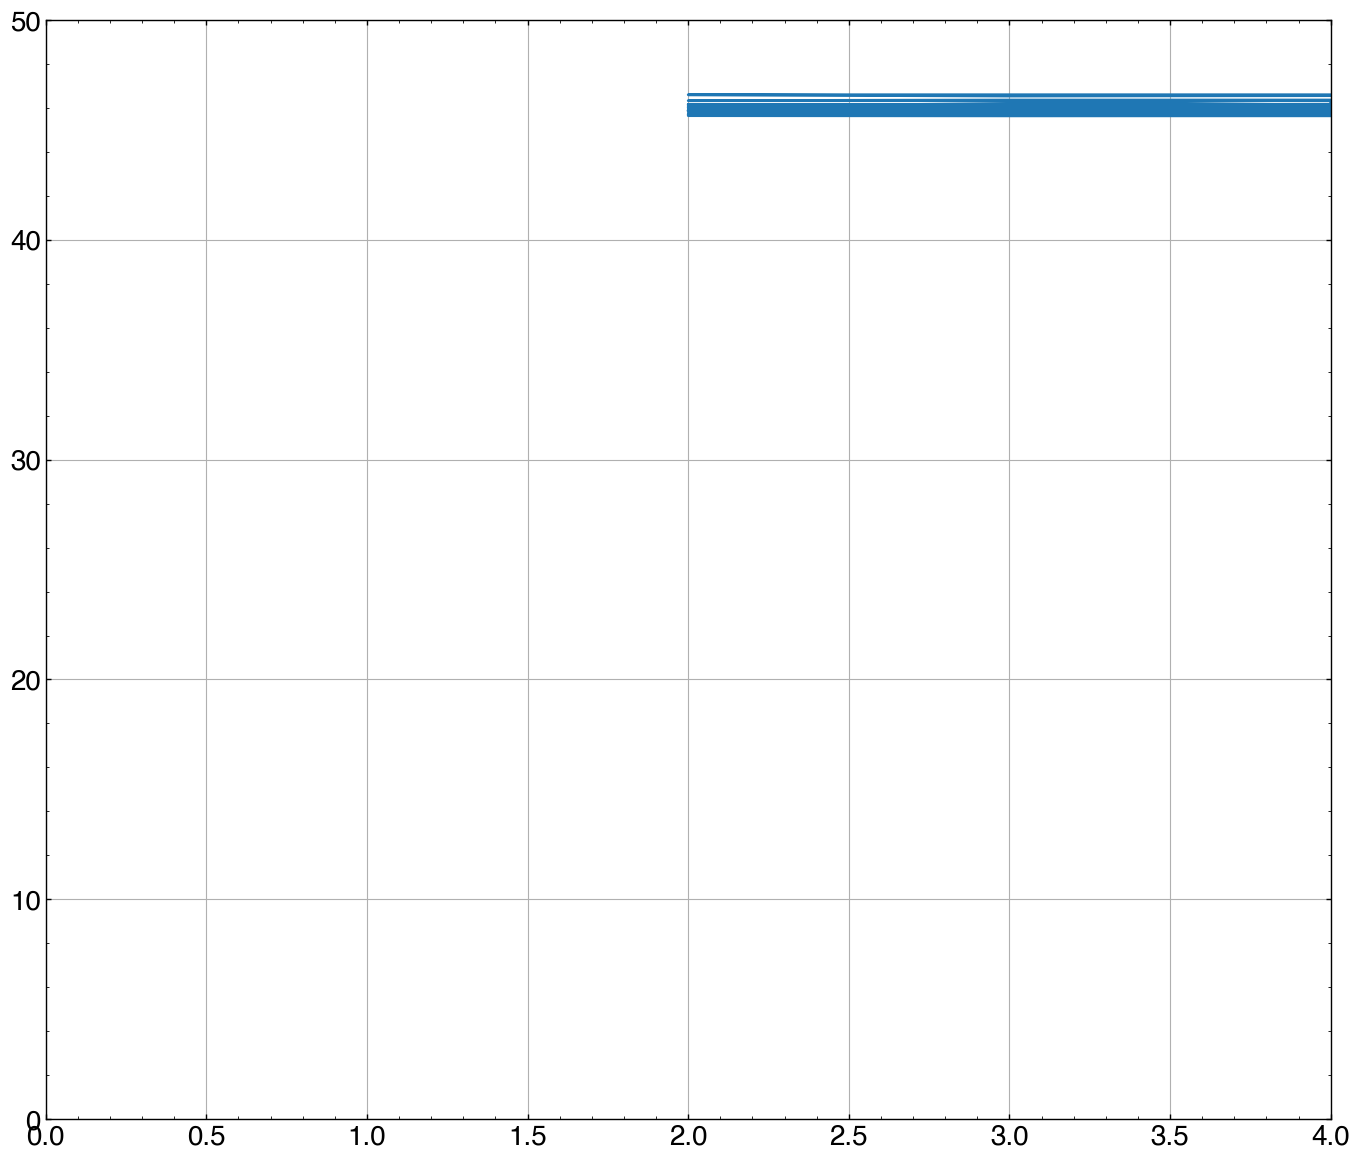

In [20]:
plt.figure()

plt.plot(data['AuxDat']['Datapoint Number'], data['AuxDat']['[VDF] Temperature 0 (°C)'])

plt.xlim((0,4))
plt.ylim((0,50))

In [5]:
df_cycle_list = []
for file in cycling_list:
    df = pd.read_csv(file)
    agg = df.groupby('Cycle Number').agg({'Discharge Capacity (Ah)': 'max'})
    df_cycle_list.append(agg)

In [17]:
df = pd.read_csv(file)
headers = df.columns.tolist()
print(headers)

['[Arbin] AC Impedance (Ω)', '[Arbin] AC Impedance Phase Angle (°)', '[Arbin] Charge Capacity (Ah)', '[Arbin] Charge Energy (Wh)', '[Arbin] Current (A)', '[Arbin] Cycle Number', '[Arbin] Datapoint Number', '[Arbin] Date Time (excel format)', '[Arbin] Discharge Capacity (Ah)', '[Arbin] Discharge Energy (Wh)', '[Arbin] dV/dT (V/s)', '[Arbin] Internal Resistance (Ω)', '[Arbin] Is Fast Capture', '[Arbin] Potential (V)', '[Arbin] Step Index', '[Arbin] Step Time (s)', '[Arbin] Test Time (s)', 'Test Cumulative Capacity (Ah)', 'Test Cumulative Energy (Wh)', 'Test Net Capacity (Ah)', 'Test Net Energy (Wh)', 'dQ/dV (Ah/V)', 'dV/dt (V/s)', 'Power (W)', 'Current Cycle Net Capacity (Ah)', 'Current Cycle Net Energy (Wh)', 'Charge Capacity (Ah)', 'Charge Energy (Wh)', 'Current (A)', 'Cycle Number', 'Datapoint Number', 'Timestamp', 'Discharge Capacity (Ah)', 'Discharge Energy (Wh)', 'Potential (V)', 'Step Index', 'Step Time (s)', 'Test Time (s)']


In [8]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2,3])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)

    hr_max = max_hours

    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    cc = df_arbin['Cycle Number']
    qq = df_arbin['Discharge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.NaN

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.NaN

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]
    out['arbin_cycle_index'] = cc.iloc[idx]
    out['arbin_discharge_capacity'] = qq.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [9]:
expt1 = fetch_experimental_data(152064)
expt3 = fetch_experimental_data(152071)
expt4 = fetch_experimental_data(152098)

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_76663/1068899767.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_76663/1068899767.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_76663/1068899767.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

# Plot the experimental data

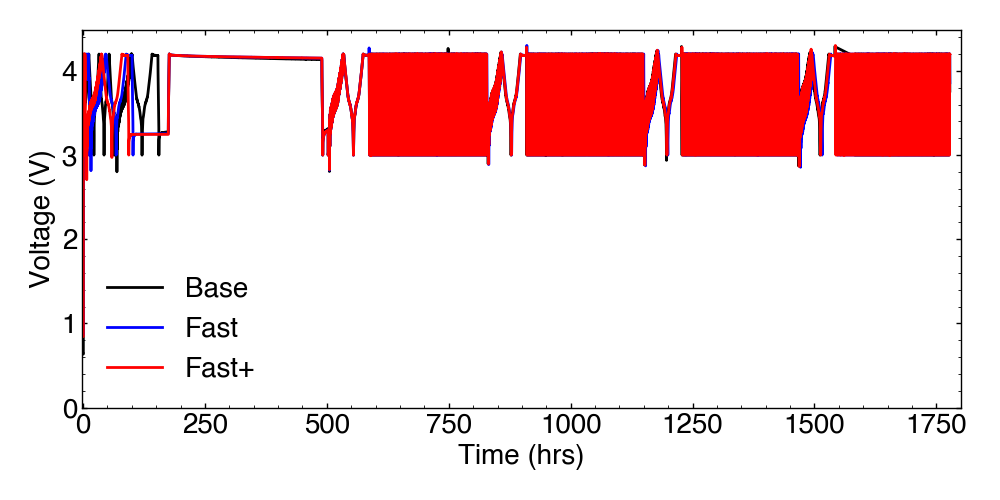

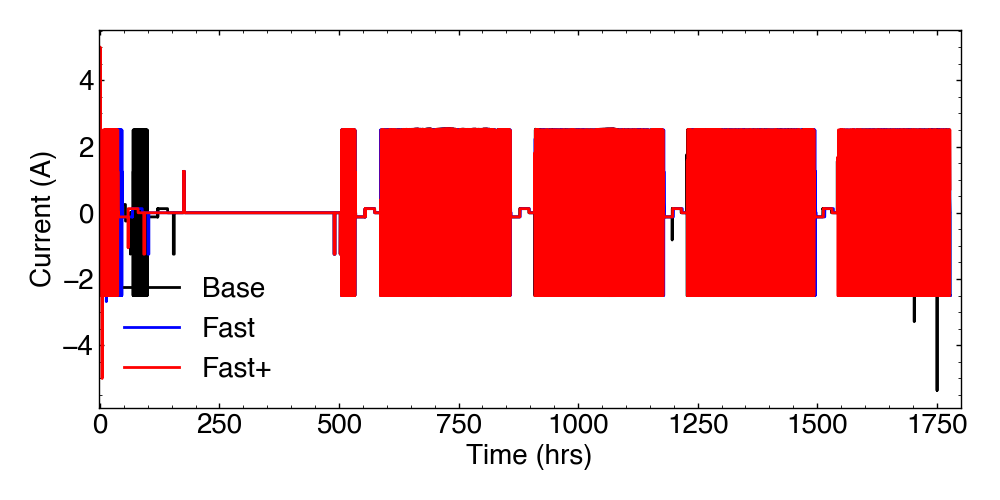

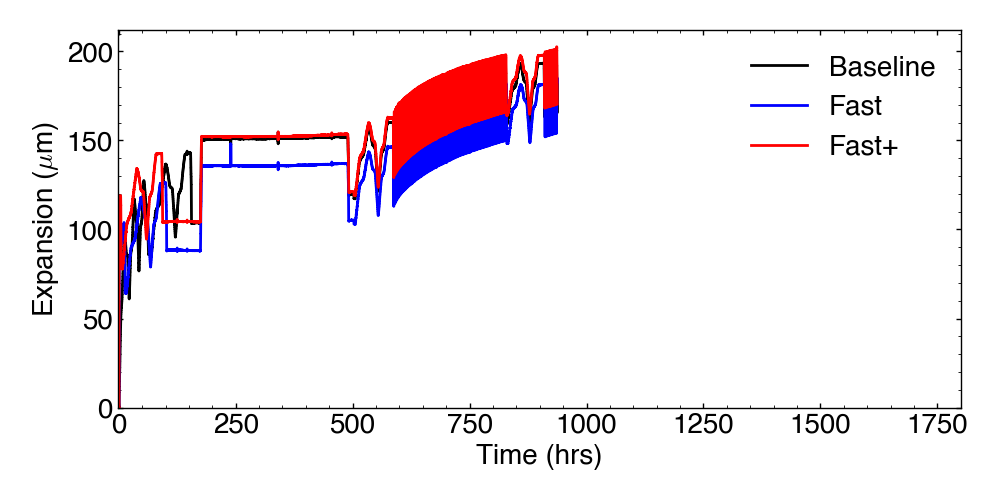

In [10]:
%matplotlib widget

# The voltage plot
plt.figure(figsize=(10,5))
ax1 = plt.gca()

XLIM = (-0.1 * 24, 1800)
ax1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label='Base')
ax1.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label='Fast')
ax1.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+')
ax1.set_xlabel('Time (hrs)')
ax1.set_ylabel('Voltage (V)')
ax1.set_ylim(bottom=0)
ax1.legend()
ax1.grid(False)
ax1.set_xlim(XLIM)

# The current plot
plt.figure(figsize=(10,5))
ax2 = plt.gca()

ax2.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax2.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax2.set_xlabel('Time (hrs)')
ax2.set_ylabel('Current (A)')
ax2.legend()
ax2.grid(False)
ax2.set_xlim(XLIM)

# The expansion plot
plt.figure(figsize=(10,5))
ax3 = plt.gca()
ax3.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label='Baseline')
ax3.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label='Fast')
ax3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+')
ax3.legend()
ax3.set_ylabel(r'Expansion ($\mu$m)')
ax3.set_ylim(bottom=0, top=212)
ax3.set_xlim(XLIM)
ax3.set_xlabel('Time (hrs)')
ax3.grid(False)

# Plot cycle by cycle data

In [11]:
df = pd.DataFrame(expt1)

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_76663/4237168010.py:1: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  df = pd.DataFrame(expt1)


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
pd.DataFrame(expt1).agg({'arbin_dischage_capacity' : ['max']}, on='arbin_cycle_index')

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_70134/1244079042.py:1: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  pd.DataFrame(expt1).agg({'arbin_dischage_capacity' : ['max']}, on='arbin_cycle_index')


ValueError: cannot reindex on an axis with duplicate labels